In [2]:
!pip install datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 4.9 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incomp

In [3]:
from datasets import load_dataset

dataset = load_dataset("TimSchopf/arxiv_categories")

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/101M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/12.7M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/12.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/163168 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20396 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20397 [00:00<?, ? examples/s]

In [4]:
# Example mapping to 8 super categories (you can adapt or simplify further)
category_mapping = {
    "cs": "Computer Science",
    "math": "Mathematics",
    "physics": "Physics",
    "astro-ph": "Astrophysics",
    "cond-mat": "Condensed Matter",
    "quant-ph": "Quantum Physics",
    "stat": "Statistics",
    "eess": "Electrical Engineering"
}

def map_label(categories):
    # Just pick the first label and extract its root
    primary = categories[0].split("->")[-1]
    for key in category_mapping:
        if primary.startswith(key):
            return category_mapping[key]
    return "Other"

# Apply mapping
for split in ['train', 'validation', 'test']:
    dataset[split] = dataset[split].map(lambda x: {'label': map_label(x['categories'])})


Map:   0%|          | 0/163168 [00:00<?, ? examples/s]

Map:   0%|          | 0/20396 [00:00<?, ? examples/s]

Map:   0%|          | 0/20397 [00:00<?, ? examples/s]

In [5]:
!pip install -U sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.2/470.2 kB 10.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 6.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 14.7 MB/s eta 0:00:00:00:0100:01


In [6]:
# Encode titles with MiniLM on GPU
from sentence_transformers import SentenceTransformer
import torch

# Detect device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load model on GPU
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

# Encode titles — set device & batch size for speed
X_train = model.encode(dataset['train']['title'], 
                       batch_size=64, 
                       show_progress_bar=True, 
                       device=device)

X_test = model.encode(dataset['test']['title'], 
                      batch_size=64, 
                      show_progress_bar=True, 
                      device=device)

# Convert labels to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(dataset['train']['label'])
y_test = le.transform(dataset['test']['label'])


Using device: cuda


Batches:   0%|          | 0/2550 [00:00<?, ?it/s]

Batches:   0%|          | 0/319 [00:00<?, ?it/s]

In [16]:
#Train MLPClassifier
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, early_stopping=True, random_state=42)
clf.fit(X_train, y_train)


MLPClassifier(early_stopping=True, hidden_layer_sizes=(128,), max_iter=1000,
              random_state=42)

Accuracy: 0.8161984605579252


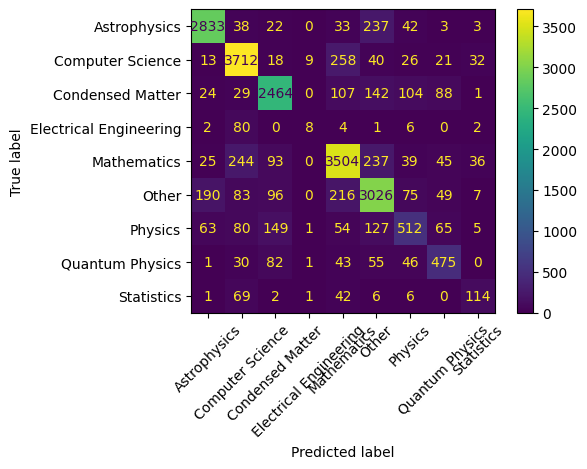

In [17]:
#Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()


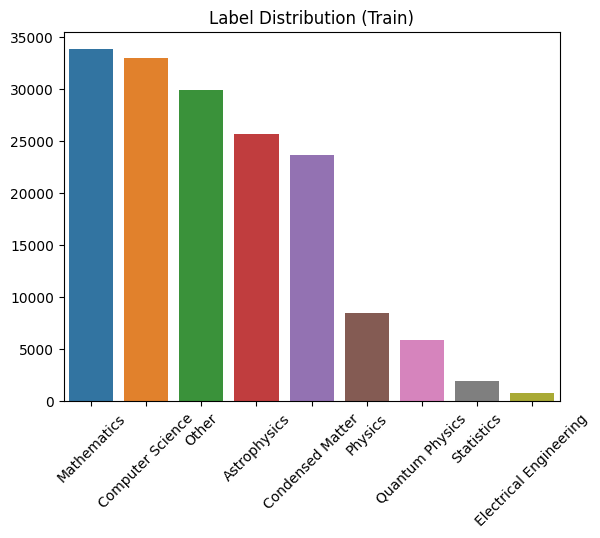

In [18]:
#✅ Bonus: Class imbalance plot
import seaborn as sns
import pandas as pd

label_counts = pd.Series(dataset['train']['label']).value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45)
plt.title("Label Distribution (Train)")
plt.show()
